In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
data_path = '../../dataset/fish_env_2022_2025.csv'
data = pd.read_csv(data_path)
print(data.columns)
print(data.head(10))

Index(['Unnamed: 0.1', 'Unnamed: 0', 'scientificName', 'taxonKey',
       'individualCount', 'organismQuantity', 'organismQuantityType', 'sex',
       'lifeStage', 'occurrenceStatus', 'continent', 'countryCode',
       'stateProvince', 'island', 'decimalLatitude', 'decimalLongitude',
       'elevation', 'elevationAccuracy', 'coordinateUncertaintyInMeters',
       'eventDate', 'year', 'month', 'day', 'datetime', 'date', 'thetao', 'so',
       'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2'],
      dtype='object')
   Unnamed: 0.1  Unnamed: 0                            scientificName  \
0             0          25       Katsuwonus pelamis (Linnaeus, 1758)   
1             1          26       Katsuwonus pelamis (Linnaeus, 1758)   
2             2          27       Katsuwonus pelamis (Linnaeus, 1758)   
3             3          28       Katsuwonus pelamis (Linnaeus, 1758)   
4             4         215        Pampus argenteus (Euphrasen, 1788)   
5             5         603  Scomberomorus commers

In [ ]:
#Missing values
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0.1                   209 non-null    int64  
 1   Unnamed: 0                     209 non-null    int64  
 2   scientificName                 209 non-null    object 
 3   taxonKey                       209 non-null    int64  
 4   individualCount                35 non-null     float64
 5   organismQuantity               1 non-null      float64
 6   organismQuantityType           1 non-null      object 
 7   sex                            3 non-null      object 
 8   lifeStage                      30 non-null     object 
 9   occurrenceStatus               209 non-null    object 
 10  continent                      209 non-null    object 
 11  countryCode                    209 non-null    object 
 12  stateProvince                  169 non-null    obj

In [ ]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
# Xác định danh sách cột theo loại
cat_features = ['countryCode', 'stateProvince']
num_features = ['thetao', 'so', 'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2']

# 1. Pipeline cho cột chữ (Categorical): Điền thiếu + Mã hóa OneHot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 2. Pipeline cho cột số (Numerical): Điền thiếu + Chuẩn hóa StandardScaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Kết hợp lại vào ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_features),
        ('num', num_transformer, num_features)
    ])

# 4. Tạo Pipeline tổng thể (từ tiền xử lý đến Model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'))
])

# Huấn luyện mô hình
# Lưu ý: OneClassSVM là học không giám sát, thường chỉ fit trên features
pipeline.fit(data[cat_features + num_features])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['countryCode',
                                                   'stateProvince']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['thetao', 'so', 'mlotst',
                                                   'uo', 'vo', 'chl', 'phyc',
                                                   'o2'])])),
                ('model', OneClassSVM(nu=0.1))])

In [ ]:
pipeline.fit(train_data)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['countryCode',
                                                   'stateProvince']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['thetao', 'so', 'mlotst',
                                                   'uo', 'vo', 'chl', 'phyc',
                                                   'o2'])])),
                ('model', OneClassSVM(nu=0.1))])

In [ ]:
# 5. Evaluation (Đánh giá)
# Với One-Class SVM, dự đoán 1 là "bình thường" (phù hợp), -1 là "ngoại lai"
test_preds = pipeline.predict(test_data)
# Tỷ lệ % các điểm test nằm trong vùng dự báo (Accuracy on presence)
accuracy_presence = list(test_preds).count(1) / len(test_preds)
print(f"Độ chính xác trên tập dữ liệu hiện diện: {accuracy_presence:.2%}")

# Lấy điểm số quyết định (càng cao càng phù hợp)
test_scores = pipeline.decision_function(test_data)

Độ chính xác trên tập dữ liệu hiện diện: 78.57%


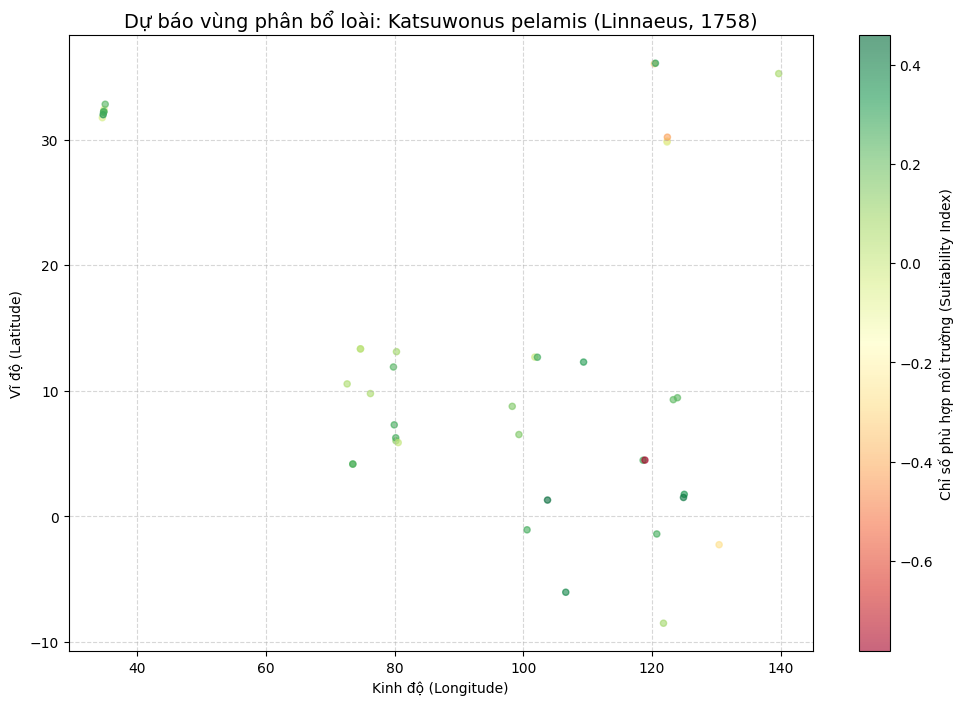

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo DataFrame kết quả để vẽ đồ thị
results = test_data.copy()
results['suitability'] = test_scores

plt.figure(figsize=(12, 8))

# Vẽ nền các điểm khảo sát
# Màu sắc (cmap) biểu thị mức độ phù hợp: đỏ (thấp) -> vàng -> xanh (cao)
sc = plt.scatter(results['decimalLongitude'], results['decimalLatitude'], 
                 c=results['suitability'], cmap='RdYlGn', s=20, alpha=0.6)

plt.colorbar(sc, label='Chỉ số phù hợp môi trường (Suitability Index)')

# Thêm tiêu đề và nhãn
plt.title(f'Dự báo vùng phân bổ loài: {data["scientificName"].iloc[0]}', fontsize=14)
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()